In [442]:
#библиотечки и т.д.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from matplotlib.pylab import norm
import scipy.stats as stats
from scipy.stats import norm, kstest

In [443]:
df = pd.read_csv("ToyotaCorolla.csv")
#The total number of records in the dataset is 1436 cars. Description of each of variables is as below:

""" Id: Unique identifier for each car entry.
Model: The model name of the Toyota Corolla.
Price: The selling price of the used car.
Age_08_04: The age of the car in months as of August 2004.
Mfg_Month: The manufacturing month of the car.
Mfg_Year: The manufacturing year of the car.
KM: The number of kilometers the car has been driven.
Fuel_type: The type of fuel the car uses (e.g., Petrol, Diesel).
HP: Horsepower, a measure of the engine's power.
Met_Color: Binary indicator for metallic paint (0 = No, 1 = Yes).
Color: The exterior color of the car.
Automatic: Binary indicator for automatic transmission (0 = No, 1 = Yes).
CC: Engine size in cubic centimeters.
Doors: Number of doors on the car.
Cylinders: Number of cylinders in the engine.
Gears: Number of gears in the transmission.
Quarterly: Quarterly tax for the car.
Weight: Weight of the car.
Mfr_Guarantee: Binary indicator for manufacturer's guarantee (0 = No, 1 = Yes).
BOVAG_Guarantee: Binary indicator for BOVAG guarantee (0 = No, 1 = Yes).
Guarantee_Period: Duration of the guarantee in months.
ABS: Binary indicator for Anti-lock Braking System (0 = No, 1 = Yes).
Airbag_1: Binary indicator for the presence of Airbag 1 (0 = No, 1 = Yes).
Airbag_2: Binary indicator for the presence of Airbag 2 (0 = No, 1 = Yes).
Airco: Binary indicator for air conditioning (0 = No, 1 = Yes).
Automatic_airco: Binary indicator for automatic air conditioning (0 = No, 1 = Yes).
Boardcomputer: Binary indicator for a board computer (0 = No, 1 = Yes).
CD_Player: Binary indicator for the presence of a CD player (0 = No, 1 = Yes).
Central_Lock: Binary indicator for central locking system (0 = No, 1 = Yes).
Powered_Windows: Binary indicator for powered windows (0 = No, 1 = Yes).
Power_Steering: Binary indicator for power steering (0 = No, 1 = Yes).
Radio: Binary indicator for a radio (0 = No, 1 = Yes).
Mistlamps: Binary indicator for mist lamps (0 = No, 1 = Yes).
Sport_Model: Binary indicator for a sport model (0 = No, 1 = Yes).
Backseat_Divider: Binary indicator for a backseat divider (0 = No, 1 = Yes).
Metallic_Rim: Binary indicator for metallic rims (0 = No, 1 = Yes).
Radio_cassette: Binary indicator for a radio cassette player (0 = No, 1 = Yes).
Parking_Assistant: Binary indicator for a parking assistant (0 = No, 1 = Yes).
Tow_Bar: Binary indicator for the presence of a tow bar (0 = No, 1 = Yes). """

" Id: Unique identifier for each car entry.\nModel: The model name of the Toyota Corolla.\nPrice: The selling price of the used car.\nAge_08_04: The age of the car in months as of August 2004.\nMfg_Month: The manufacturing month of the car.\nMfg_Year: The manufacturing year of the car.\nKM: The number of kilometers the car has been driven.\nFuel_type: The type of fuel the car uses (e.g., Petrol, Diesel).\nHP: Horsepower, a measure of the engine's power.\nMet_Color: Binary indicator for metallic paint (0 = No, 1 = Yes).\nColor: The exterior color of the car.\nAutomatic: Binary indicator for automatic transmission (0 = No, 1 = Yes).\nCC: Engine size in cubic centimeters.\nDoors: Number of doors on the car.\nCylinders: Number of cylinders in the engine.\nGears: Number of gears in the transmission.\nQuarterly: Quarterly tax for the car.\nWeight: Weight of the car.\nMfr_Guarantee: Binary indicator for manufacturer's guarantee (0 = No, 1 = Yes).\nBOVAG_Guarantee: Binary indicator for BOVAG g

In [444]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [445]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [446]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [447]:
df.nunique()

Id                   1436
Model                 319
Price                 236
Age_08_04              77
Mfg_Month              12
Mfg_Year                7
KM                   1263
Fuel_Type               3
HP                     12
Met_Color               2
Color                  10
Automatic               2
CC                     13
Doors                   4
Cylinders               1
Gears                   4
Quarterly_Tax          13
Weight                 59
Mfr_Guarantee           2
BOVAG_Guarantee         2
Guarantee_Period        9
ABS                     2
Airbag_1                2
Airbag_2                2
Airco                   2
Automatic_airco         2
Boardcomputer           2
CD_Player               2
Central_Lock            2
Powered_Windows         2
Power_Steering          2
Radio                   2
Mistlamps               2
Sport_Model             2
Backseat_Divider        2
Metallic_Rim            2
Radio_cassette          2
Parking_Assistant       2
Tow_Bar     

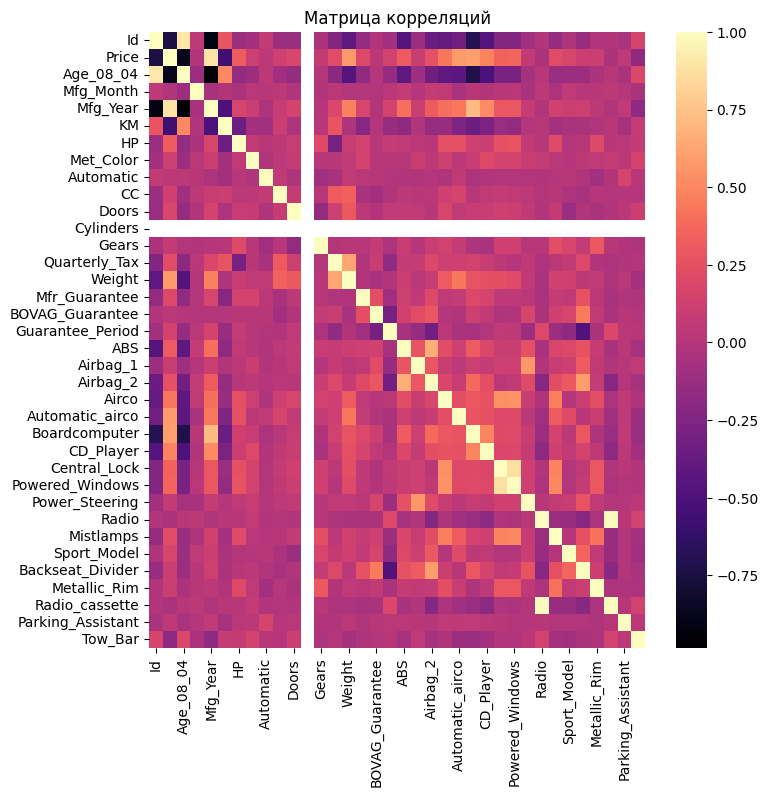

In [448]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=False, ax=ax)
plt.title("Матрица корреляций")
plt.show()

In [449]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [450]:
# уберем id и модель - первое вообще не имеет смысла, второе - слишком много типов, при кодировании получим 300+ признаков
df = df.drop(['Id', 'Model'], axis=1)
#кодирование категориальных признаков 
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [451]:
# Смотрим на топ-10 признаков, которые сильнее всего коррелируют с таргетом
correlations = df.corr()['Price']
top_correlations = correlations.abs().sort_values(ascending=False)
print(top_correlations.head(10))

Price              1.000000
Mfg_Year           0.885159
Age_08_04          0.876590
Boardcomputer      0.601292
Automatic_airco    0.588262
Weight             0.581198
KM                 0.569960
CD_Player          0.481374
Airco              0.429259
Powered_Windows    0.356518
Name: Price, dtype: float64


In [452]:
lowest_correlations = correlations.abs().sort_values(ascending=True)
print(lowest_correlations.head(10))

Color_Blue          0.014431
Color_Violet        0.016848
Mfg_Month           0.018138
Color_Yellow        0.022726
BOVAG_Guarantee     0.028133
Color_Silver        0.028562
Automatic           0.033081
Color_Black         0.034896
Fuel_Type_Petrol    0.038516
Radio               0.041887
Name: Price, dtype: float64


In [453]:
df.head()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,13500,23,10,2002,46986,90,1,0,2000,3,...,0,0,1,0,0,0,0,0,0,0
1,13750,23,10,2002,72937,90,1,0,2000,3,...,0,0,0,0,0,0,1,0,0,0
2,13950,24,9,2002,41711,90,1,0,2000,3,...,0,0,1,0,0,0,0,0,0,0
3,14950,26,7,2002,48000,90,0,0,2000,3,...,0,1,0,0,0,0,0,0,0,0
4,13750,30,3,2002,38500,90,0,0,2000,3,...,0,1,0,0,0,0,0,0,0,0


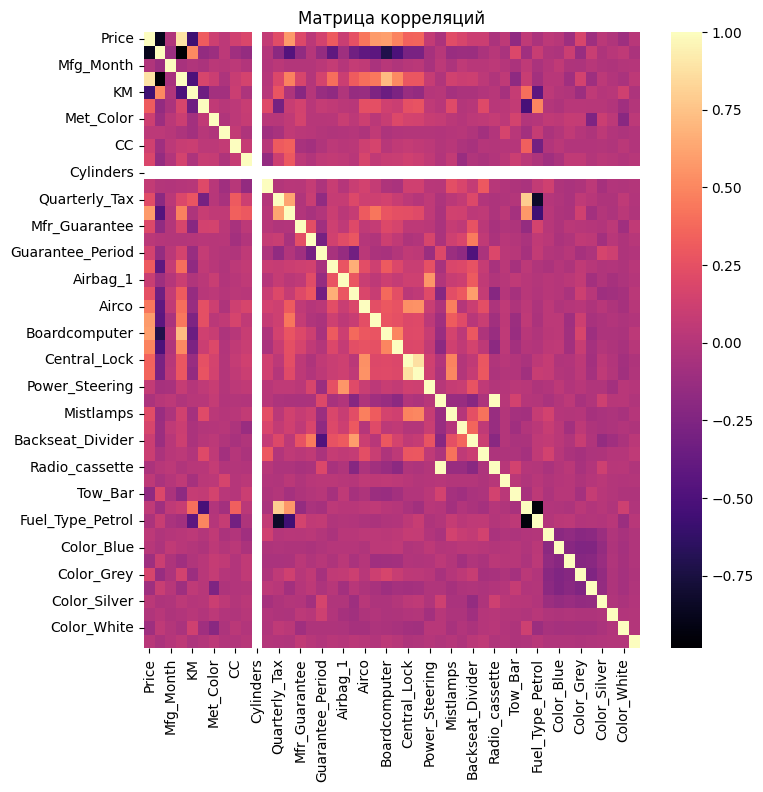

In [454]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=False, fmt=".2f")
plt.title("Матрица корреляций")
plt.show()

In [455]:
print(df['Cylinders'].describe())

count    1436.0
mean        4.0
std         0.0
min         4.0
25%         4.0
50%         4.0
75%         4.0
max         4.0
Name: Cylinders, dtype: float64


In [456]:
df = df.drop(columns=['Cylinders'])
#у всех 4 цилиндра, нет никакой информации - можно выбросить

In [457]:
y = df['Price']
X = df.drop(columns=['Price'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#делим на train и test, 20% на тест
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1148, 44) (288, 44) (1148,) (288,)


In [458]:
X.head()

,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Gears,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,23,10,2002,46986,90,1,0,2000,3,5,...,0,0,1,0,0,0,0,0,0,0
1,23,10,2002,72937,90,1,0,2000,3,5,...,0,0,0,0,0,0,1,0,0,0
2,24,9,2002,41711,90,1,0,2000,3,5,...,0,0,1,0,0,0,0,0,0,0
3,26,7,2002,48000,90,0,0,2000,3,5,...,0,1,0,0,0,0,0,0,0,0
4,30,3,2002,38500,90,0,0,2000,3,5,...,0,1,0,0,0,0,0,0,0,0


In [459]:
y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [460]:
#просто линейная регрессия


linear_steps = [
    #('scaler', StandardScaler()), #для обычной регрессии нет необходимости
    ('model', LinearRegression()) 
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

#время обучения 0.1 с - быстро, но ожидаемо для такой простой вещи как линейная регрессия

Linear Regression Results:
CV Mean:  0.8056601876267614
R2_score (train):  0.9142143867608407
R2_score (test):  0.886516828921031
RMSE:  1230.5210233963364
MAPE:  0.08485258630548345


In [461]:
#линейная регрессия с полиномиальными признаками


linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    #('model', Ridge(alpha=50.0))
]
regressor_linear_pol_noridge = Pipeline(linear_steps)
regressor_linear_pol_noridge.fit(X_train, y_train)

y_pred_linear_train = regressor_linear_pol_noridge.predict(X_train)
y_pred_linear_test = regressor_linear_pol_noridge.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear_pol_noridge, X=X_train, y=y_train, cv=10)

print("Linear Regression (polynomial) Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

#R2_score (test):  -0.38 - лютое переобучение без регуляризации

Linear Regression (polynomial) Results:
CV Mean:  -292092.53679417825
R2_score (train):  0.9770383447526645
R2_score (test):  -0.38681400840624014
RMSE:  4301.623702702517
MAPE:  0.16359916665097232


In [462]:
#линейная регрессия с полиномиальными признаками и регуляризацией


linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=50.0)) #добавляем регуляризацию, чтобы избежать переобучения
]
regressor_linear_pol = Pipeline(linear_steps)
regressor_linear_pol.fit(X_train, y_train)

y_pred_linear_train_pol = regressor_linear_pol.predict(X_train)
y_pred_linear_test_pol = regressor_linear_pol.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train_pol)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test_pol)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test_pol))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test_pol)
cv_linear = cross_val_score(estimator=regressor_linear_pol, X=X_train, y=y_train, cv=10)

print("Linear Regression (polynomial, Ridge) Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

#результат r2 test 0.91 - выше чем у просто регрессии
#rmse ниже, mape не отличается
#это значит, что уменьшилось количество выбросов, но общая точность не изменилась (хотя 8% уже можно считать хорошим результатом)
#сходство оценок r2 на train/test говорит, чтопереобучения нет, модель хорошо обобщается на тестовую выборку
#время обучения 1.0 с - заметно больше, но стоит того при улучшении результатов
#по сравнению с предыдущим (без ridge) уменьшилось, т.к. быстрее сходимость с регуляризацией, меньше итераций нужно для обучения модели

Linear Regression (polynomial, Ridge) Results:
CV Mean:  0.8643759852660778
R2_score (train):  0.9589489355786152
R2_score (test):  0.9103707423877422
RMSE:  1093.574075469104
MAPE:  0.08039844170987644


In [463]:
#попробуем подобрать лучшее значение alpha для Ridge

alphas = [0.1, 1.0, 10.0, 50.0, 100.0]
best_alpha = None
best_cv_score = -np.inf
for alpha in alphas:
    linear_steps = [
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ]
    regressor_linear = Pipeline(linear_steps)
    cv_score = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10).mean()
    
    if cv_score > best_cv_score:
        best_cv_score = cv_score
        best_alpha = alpha

print("Best alpha: ", best_alpha)
#лучшее значение alpha 100.0

Best alpha:  100.0


In [464]:
y_train.ravel().shape

/var/folders/zw/j9h9wg0j77z0xcmnlr_dj9080000gn/T/ipykernel_79199/1078338228.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train.ravel().shape


(1148,)

/var/folders/zw/j9h9wg0j77z0xcmnlr_dj9080000gn/T/ipykernel_79199/1910445615.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals = (y_train.ravel() - y_pred_linear_train.ravel())


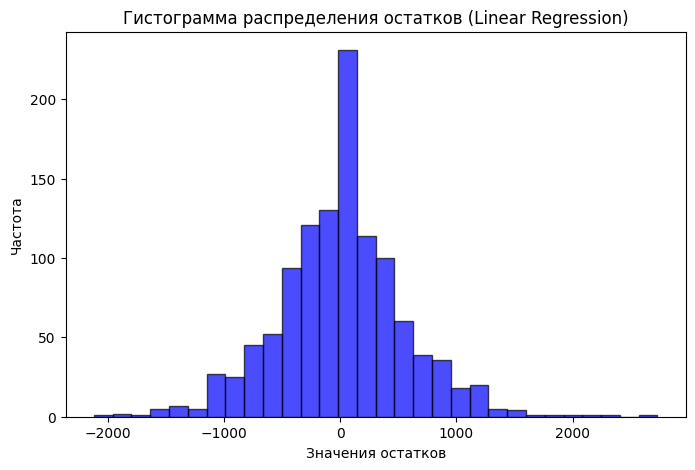

Статистика Колмогорова-Смирнова: 0.0640, P-значение: 1.5616e-04
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


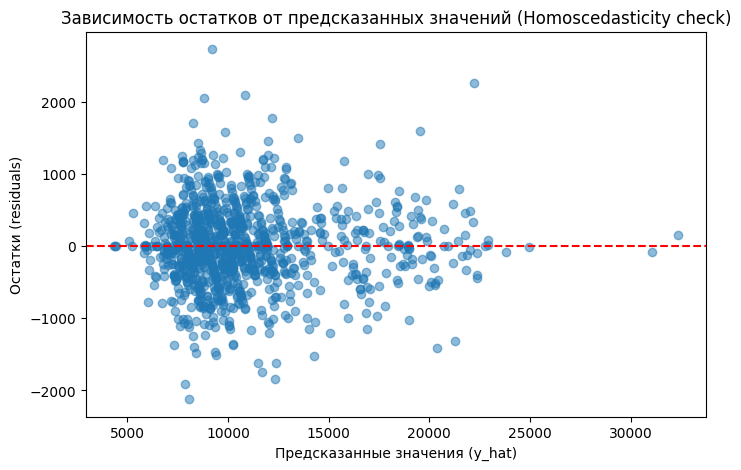

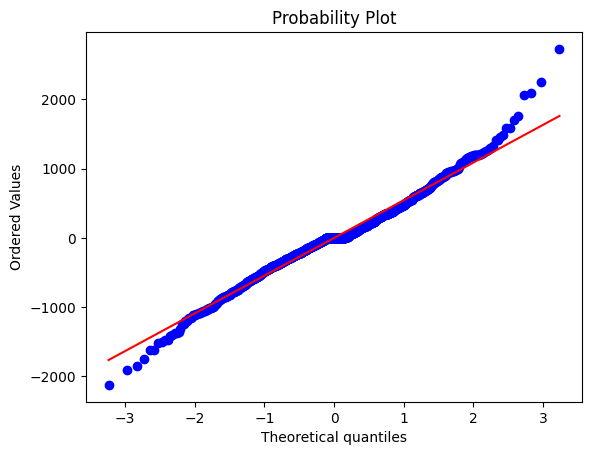

In [ ]:
#обычная регрессия

residuals = (y_train.ravel() - y_pred_linear_train.ravel())

def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, 'norm', args=(residuals_mean, residuals_std))
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

#гипотеза о нормлальности отклонена

/var/folders/zw/j9h9wg0j77z0xcmnlr_dj9080000gn/T/ipykernel_79199/614447512.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals = (y_train.ravel() - y_pred_linear_train_pol.ravel())


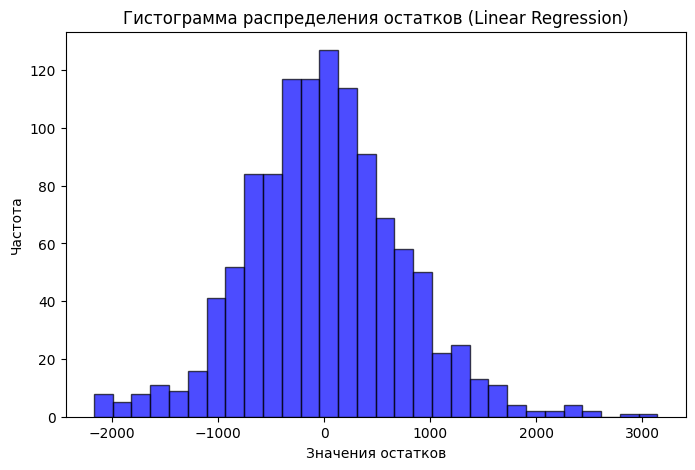

Статистика Колмогорова-Смирнова: 0.0327, P-значение: 1.6847e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


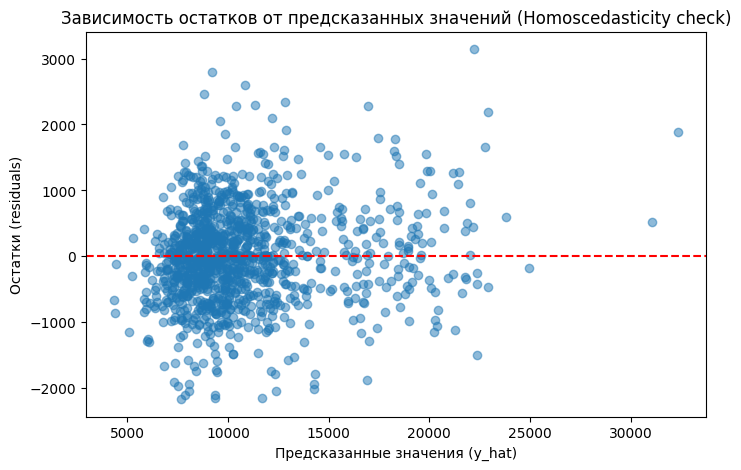

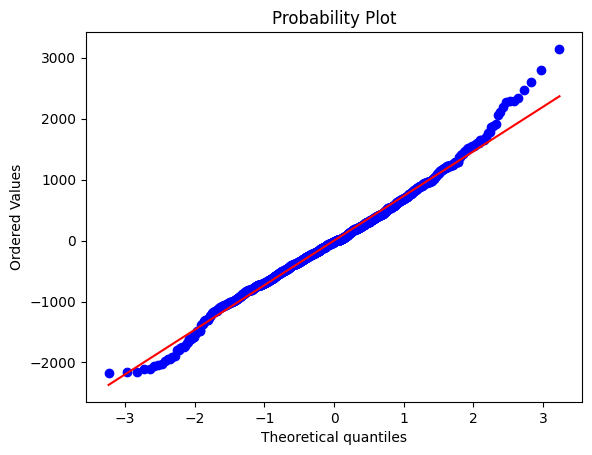

In [ ]:
#для полиномиальной с Ridge

residuals = (y_train.ravel() - y_pred_linear_train_pol.ravel())

def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, 'norm', args=(residuals_mean, residuals_std))
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

In [ ]:
#гипотеза теперь принимается
#таким образом, при небольшой разнице по статистике, остатки модели стали значительно лучше